# Diagrama de McCabe-Thiele

El diagrama de McCabe-Thiele es una herramienta gráfica clásica para estimar etapas teóricas en destilación binaria. El método fue presentado como diseño gráfico de columnas de fraccionamiento y sigue siendo útil para explicar balances de equilibrio y líneas de operación {cite:p}`mccabe1925graphical_design_fractionating_columns`.

En este ejemplo se usa volatilidad relativa constante:

$$
y^*(x)=\frac{\alpha x}{1+(\alpha-1)x}
$$

La línea rectificante se calcula con:

$$
y=\frac{R}{R+1}x+\frac{x_D}{R+1}
$$

```{admonition} Qué puedes modificar
:class: dropdown
Cambia `R`, `alpha`, `xD`, `xF` o `xB`. Un reflujo mayor acerca la línea rectificante a la diagonal y normalmente reduce el número de etapas, pero aumenta el coste energético.
```


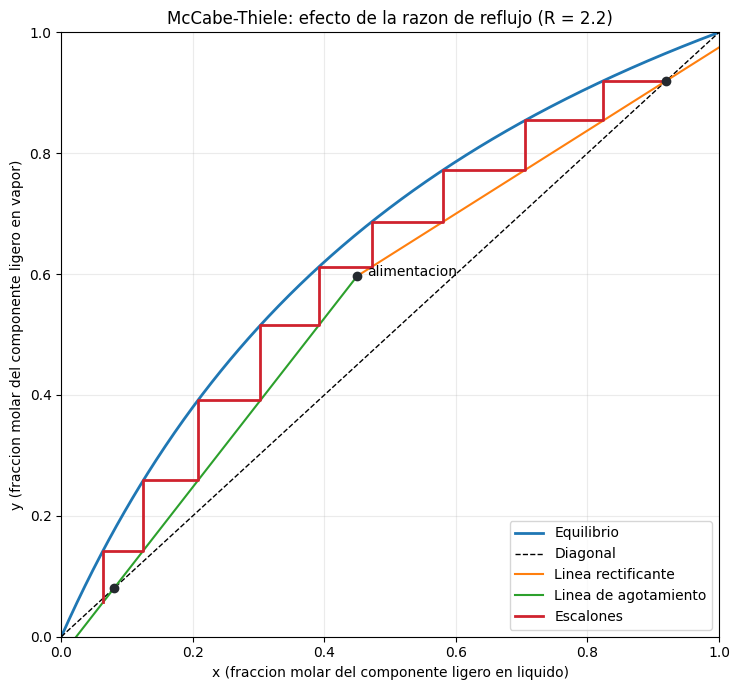

Etapas teoricas aproximadas: 9
xD=0.92, xF=0.45, xB=0.08, alpha=2.45, R=2.20


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
alpha = 2.45   # relative volatility
xF = 0.45      # feed composition
xD = 0.92      # distillate composition
xB = 0.08      # bottoms composition
R = 2.2        # reflux ratio
max_stages = 60


def y_equilibrium(x, alpha):
    return alpha * x / (1 + (alpha - 1) * x)


def x_equilibrium_from_y(y, alpha):
    return y / (alpha - (alpha - 1) * y)


def y_rectifying(x, R, xD):
    return (R / (R + 1)) * x + xD / (R + 1)

# Saturated-liquid feed: q-line is vertical at xF. The stripping line is drawn
# through the feed intersection and the bottoms point on the diagonal.
y_feed = y_rectifying(xF, R, xD)
m_strip = (y_feed - xB) / (xF - xB)
b_strip = xB - m_strip * xB

def y_operating(x):
    return y_rectifying(x, R, xD) if x >= xF else m_strip * x + b_strip

# Staircase construction.
stair_x = [xD]
stair_y = [xD]
stages = 0
x_current = xD
y_current = xD
while x_current > xB and stages < max_stages:
    x_eq = x_equilibrium_from_y(y_current, alpha)
    stair_x.extend([x_eq, x_eq])
    stair_y.extend([y_current, y_operating(x_eq)])
    x_current = x_eq
    y_current = y_operating(x_eq)
    stages += 1

x = np.linspace(0, 1, 500)
plt.figure(figsize=(7.5, 7))
plt.plot(x, y_equilibrium(x, alpha), label="Equilibrio", linewidth=2)
plt.plot(x, x, "k--", label="Diagonal", linewidth=1)
plt.plot(x[x >= xF], y_rectifying(x[x >= xF], R, xD), label="Linea rectificante")
plt.plot(x[x <= xF], m_strip * x[x <= xF] + b_strip, label="Linea de agotamiento")
plt.plot(stair_x, stair_y, color="#cf222e", linewidth=2, label="Escalones")
plt.scatter([xF, xD, xB], [y_feed, xD, xB], color="#24292f", zorder=5)
plt.text(xF + 0.015, y_feed, "alimentacion")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("x (fraccion molar del componente ligero en liquido)")
plt.ylabel("y (fraccion molar del componente ligero en vapor)")
plt.title("McCabe-Thiele: efecto de la razon de reflujo (R = " + str(R) + ")")
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Etapas teoricas aproximadas: {stages}")
print(f"xD={xD:.2f}, xF={xF:.2f}, xB={xB:.2f}, alpha={alpha:.2f}, R={R:.2f}")


## Lectura del resultado

Al aumentar la razón de reflujo, la línea rectificante se acerca a la diagonal y se reducen las etapas necesarias. El coste energético, sin embargo, aumenta porque se recircula más líquido dentro de la columna.

```{admonition} Lectura guiada
:class: dropdown
Cuenta los escalones rojos entre $x_D$ y $x_B$. Cada escalón representa una etapa ideal: horizontal hasta equilibrio, vertical hasta la línea de operación.
```
